## Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

## Загрузка датасета

In [3]:
DATA_PATH = "../data/"
df = pd.read_csv(DATA_PATH + "coursera_courses.csv")

In [4]:
df.head()

,course_title,course_organization,course_certificate_type,course_time,course_rating,course_reviews_num,course_difficulty,course_url,course_students_enrolled,course_skills,course_summary,course_description
0,(ISC)² Systems Security Certified Practitioner...,ISC2,Specialization,3 - 6 Months,4.7,492,Beginner,https://www.coursera.org/specializations/sscp-...,"6,958","['Risk Management', 'Access Control', 'Asset',...",[],Pursue better IT security job opportunities an...
1,.NET FullStack Developer,Board Infinity,Specialization,1 - 3 Months,4.3,51,Intermediate,https://www.coursera.org/specializations/dot-n...,"2,531","['Web API', 'Web Development', 'Cascading Styl...",['Master .NET full stack web dev: from .NET co...,Develop the proficiency required to design and...
2,21st Century Energy Transition: how do we make...,University of Alberta,Course,1 - 3 Months,4.8,62,Beginner,https://www.coursera.org/learn/21st-century-en...,"4,377",[],['Understand the complexity of systems supplyi...,"Affordable, abundant and reliable energy is fu..."
3,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,Course,1 - 3 Months,4.7,517,Intermediate,https://www.coursera.org/learn/crash-course-in...,"39,004","['Instrumental Variable', 'Propensity Score Ma...",[],We have all heard the phrase “correlation does...
4,A life with ADHD,University of Geneva,Course,1 - 3 Months,NaN,NaN,Beginner,https://www.coursera.org/learn/life-with-adhd,NaN,"['differential diagnosis and comorbidities', '...",[' Understand what ADHD is and the challenges ...,What is ADHD and what are the challenges that ...


## Сколько данных в датасете?

In [22]:
print(f"Count of objects in df: {len(df)}")
print(f"Count of columns: {len(df.columns)}")
print(f"\nColumns: {", ".join(list(df.columns))}")

Count of objects in df: 1000
Count of columns: 15


'\nColumns: course_title, course_organization, course_certificate_type, course_time, course_rating, course_reviews_num, course_difficulty, course_url, course_students_enrolled, course_skills, course_summary, course_description, students_clean, reviews_clean, skills_list'

## Типы данных колонок

In [21]:
print("-- Column types:")
df.dtypes

-- Column types:


course_title                    str
course_organization             str
course_certificate_type         str
course_time                     str
course_rating               float64
course_reviews_num              str
course_difficulty               str
course_url                      str
course_students_enrolled        str
course_skills                   str
course_summary                  str
course_description              str
students_clean              float64
reviews_clean               float64
skills_list                  object
dtype: object

## Пропуски в данных

In [24]:
print("-- Gaps in data:")
df.isnull().sum()

-- Gaps in data:


course_title                 0
course_organization          0
course_certificate_type      0
course_time                  0
course_rating                6
course_reviews_num           6
course_difficulty            0
course_url                   0
course_students_enrolled    41
course_skills                0
course_summary               0
course_description           1
students_clean              41
reviews_clean                6
skills_list                  0
dtype: int64

## Очистка данных от лишних знаков

In [26]:
df["students_clean"] = df["course_students_enrolled"].str.replace(",", "").str.replace("k", "000").astype(float)
df["reviews_clean"] = df["course_reviews_num"].str.replace(",", "").str.replace("k", "000").astype(float)

## Распределение сложности курсов

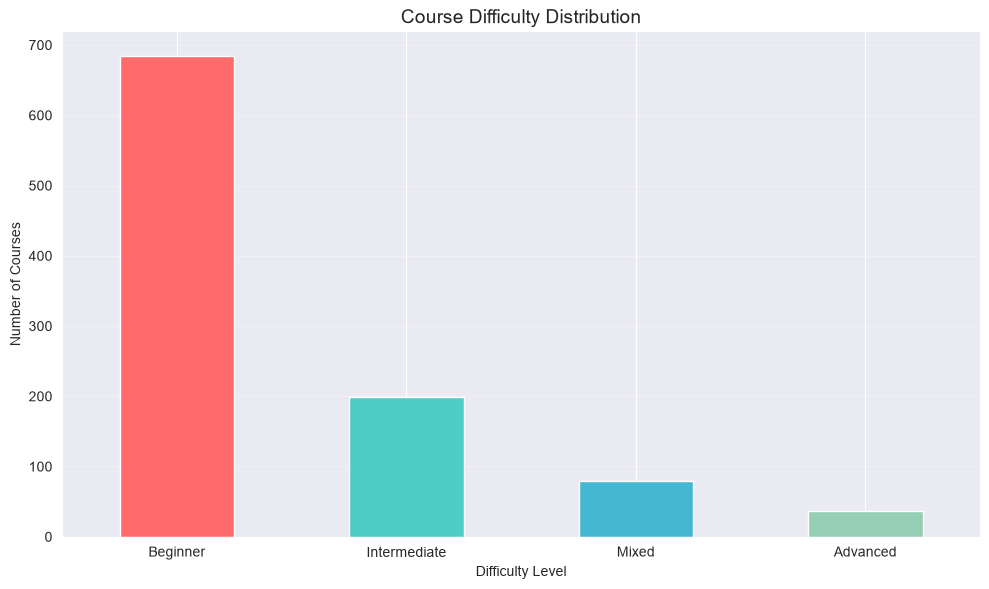

In [9]:
plt.figure(figsize=(10, 6))
df["course_difficulty"].value_counts().plot(kind="bar", color=["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4"])
plt.title("Course Difficulty Distribution", fontsize=14)
plt.xlabel("Difficulty Level")
plt.ylabel("Number of Courses")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Большинство курсов - для новичков, такие курсы будет рекомендовать модель, если пользователь только что зарегистрировался на платформе. Курсов для профессионалов меньше 50.

## Распределение рейтингов курсов

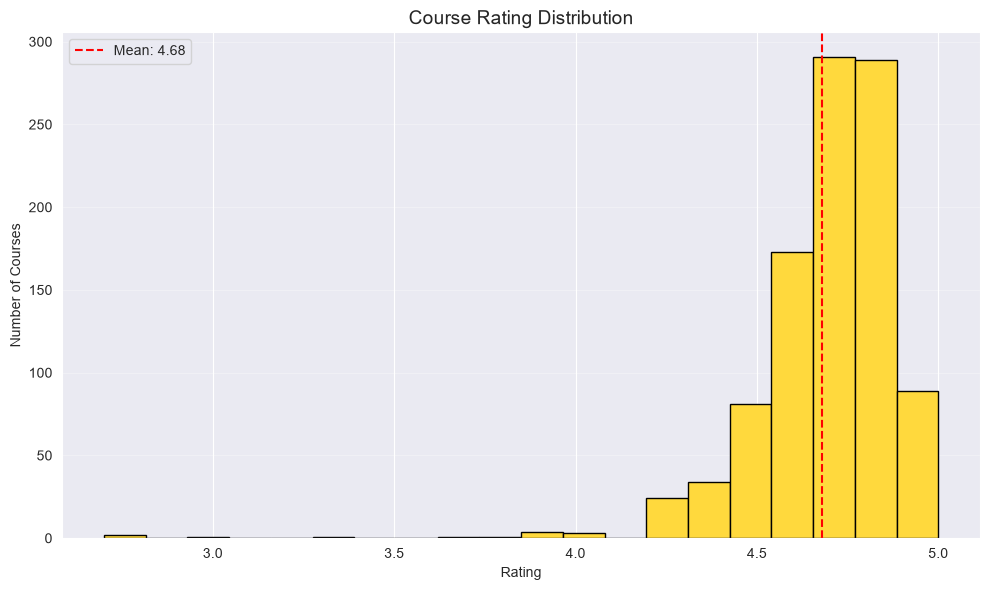

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df["course_rating"], bins=20, color="#FFD93D", edgecolor="black")
plt.axvline(df["course_rating"].mean(), color="red", linestyle="--", label=f"Mean: {df['course_rating'].mean():.2f}")
plt.title("Course Rating Distribution", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Number of Courses")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Средняя оценка курсов - 4.68. Большинство пользователей ставят положительные оценки на курсы, нейтральных и негативных отзывов - практически не наблюдается, возможно, это связано с тем, что если курс человеку не понравился, то он его не заканчивает и забрасывает до написания отзыва.

## Распределение студентов по курсам

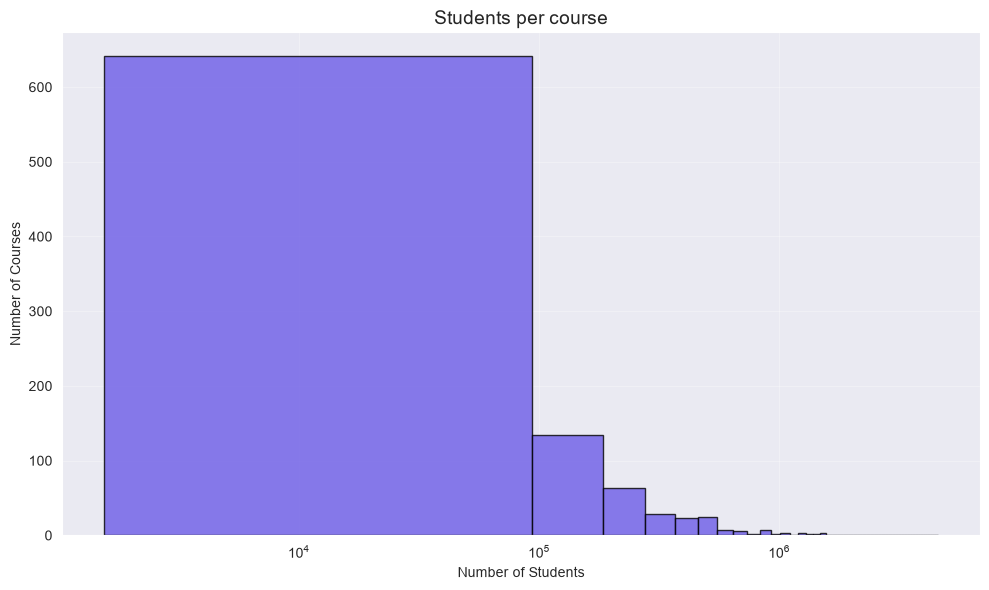

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df["students_clean"], bins=50, color="#6C5CE7", edgecolor="black", alpha=0.8)
plt.xscale("log")
plt.title("Students per course", fontsize=14)
plt.xlabel("Number of Students")
plt.ylabel("Number of Courses")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Большинство курсов имеют мало студентов, тогда как всего несколько курсов имеют миллионы студентов. Самые популярные курсы так же можно рекомендовать новым пользователям.

## Топ-10 организаций по количеству курсов

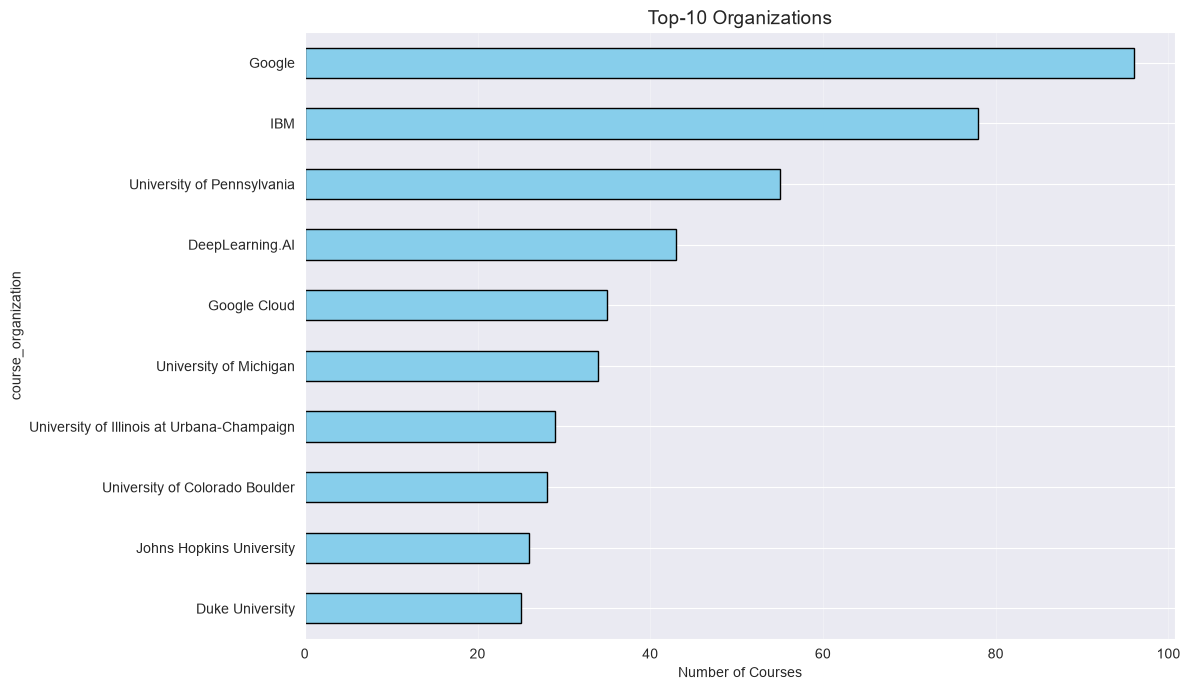

In [12]:
plt.figure(figsize=(12, 7))
top_orgs = df["course_organization"].value_counts().head(10)
top_orgs.plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Top-10 Organizations", fontsize=14)
plt.xlabel("Number of Courses")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Google, IBM, UoP - лидеры по количеству курсов. Если пользователь имеет в профиле пару курсов от конкретной компании, то можно рекомендовать ему курсы от этой же компании, которые он еще не видел.

## Распределение длительности курсов

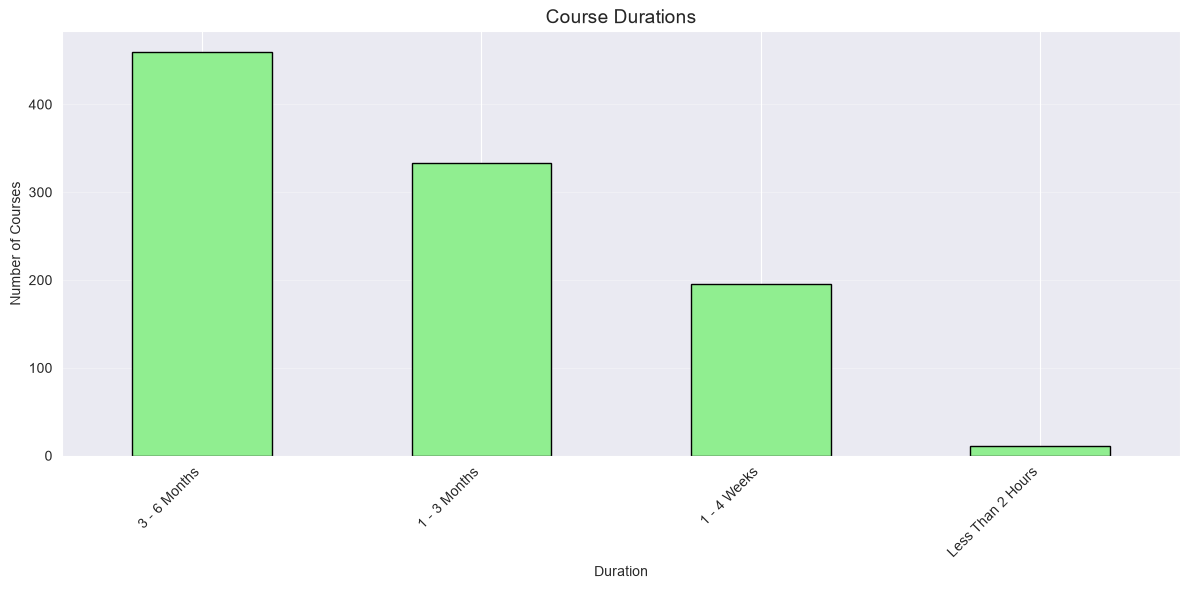

In [13]:
plt.figure(figsize=(12, 6))
top_times = df["course_time"].value_counts().head(8)
top_times.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Course Durations", fontsize=14)
plt.xlabel("Duration")
plt.ylabel("Number of Courses")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Организаторы предпочитают создание длительных, полноценных курсов.

## Распределение типов курсов

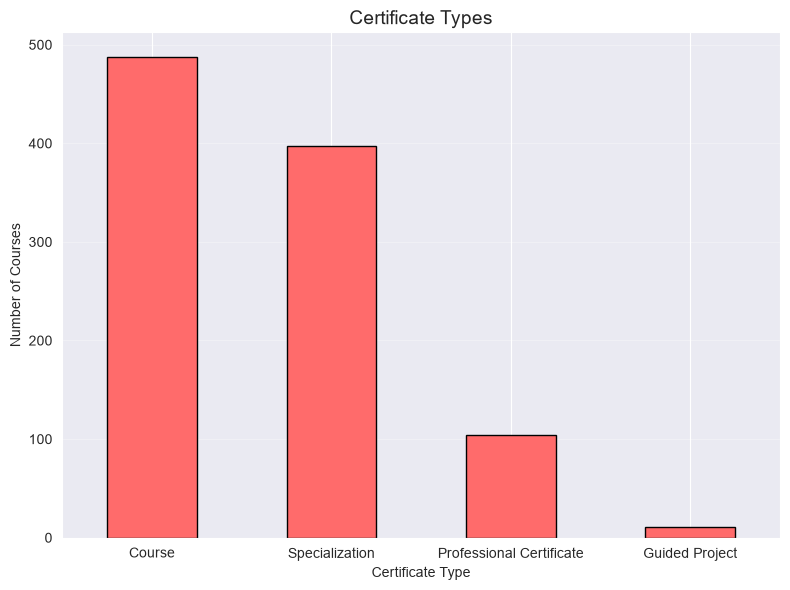

In [14]:
plt.figure(figsize=(8, 6))
df["course_certificate_type"].value_counts().plot(kind="bar", color="#FF6B6B", edgecolor="black")
plt.title("Certificate Types", fontsize=14)
plt.xlabel("Certificate Type")
plt.ylabel("Number of Courses")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Простые курсы более популярны, чем все профессиональные вместе взятые.

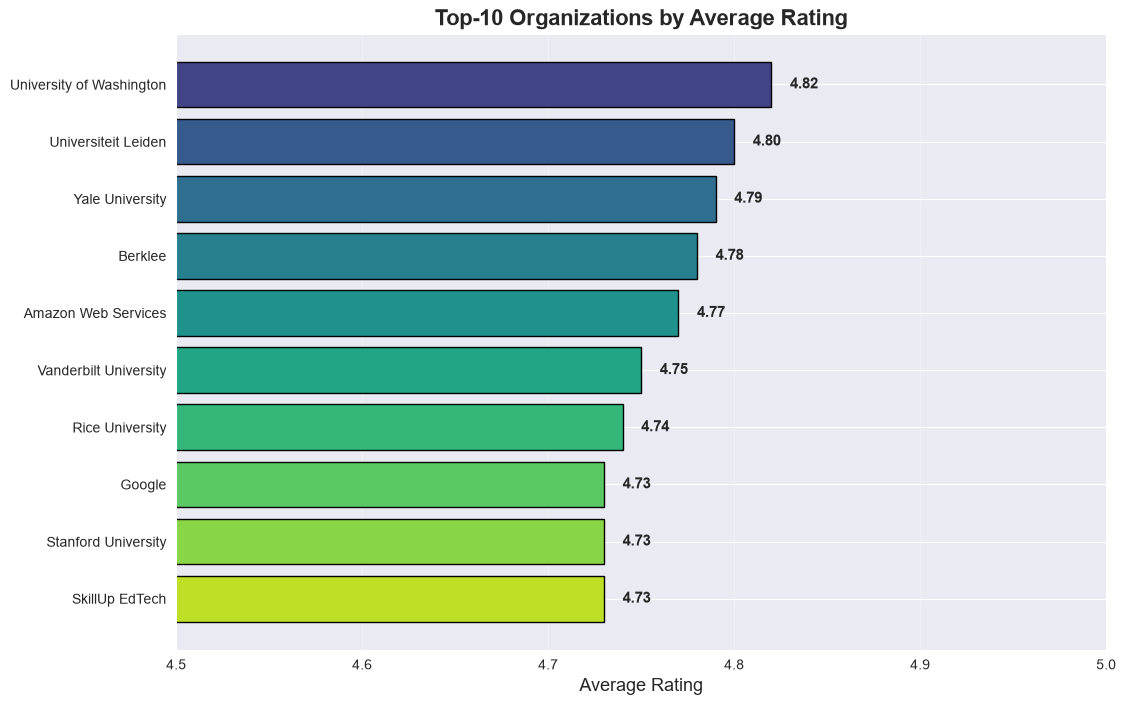

In [42]:
plt.figure(figsize=(12, 8))
avg_rating_by_org = df.groupby("course_organization")["course_rating"].agg(["mean", "count"]).round(2)
avg_rating_by_org.columns = ["avg_rating", "num_courses"]
avg_rating_by_org = avg_rating_by_org.sort_values("avg_rating", ascending=False)
top_orgs_by_rating = avg_rating_by_org[avg_rating_by_org["num_courses"] >= 5].head(10)

plot_data = top_orgs_by_rating.sort_values("avg_rating", ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_data)))[::-1]

bars = plt.barh(plot_data.index, plot_data["avg_rating"], color=colors, edgecolor="black", linewidth=1)

for bar, value in zip(bars, plot_data["avg_rating"]):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{value:.2f}", ha="left", va="center", fontweight="bold", fontsize=11)

plt.title("Top-10 Organizations by Average Rating", fontsize=16, fontweight="bold")
plt.xlabel("Average Rating", fontsize=13)
plt.xlim(4.5, 5.0)
plt.grid(axis="x", alpha=0.3)
plt.show()

#### Вывод
Первые 3 организации в топе - университеты, они делают самые качественные курсы, которые смело можно рекомендовать новым пользователям, если они не обладают высокой сложостью.

## Топ-15 популярных навыков, которые дают курсы

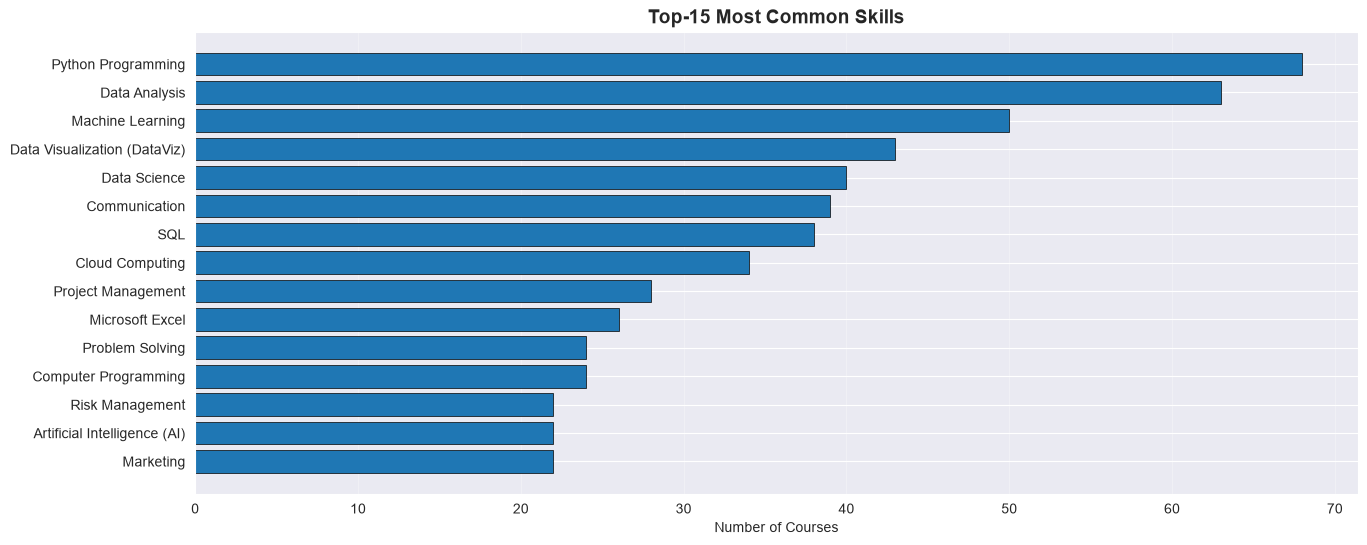

In [51]:
from collections import Counter

def extract_skills(skill_str):
    try:
        if isinstance(skill_str, str):
            if skill_str.startswith("["):
                return ast.literal_eval(skill_str)
            return [s.strip() for s in skill_str.split(",")]
    except:
        pass
    return []

df["skills_list"] = df["course_skills"].apply(extract_skills)
all_skills = [skill for skills in df["skills_list"] for skill in skills if skill]
skill_counts = Counter(all_skills)

fig, axes = plt.subplots(1, 1, figsize=(15, 6))

top_skills = skill_counts.most_common(15)
skills, counts = zip(*top_skills)

bars = axes.barh(skills, counts, edgecolor="black", linewidth=0.5)
axes.set_title("Top-15 Most Common Skills", fontsize=14, fontweight="bold")
axes.set_xlabel("Number of Courses")
axes.invert_yaxis()
axes.grid(axis="x", alpha=0.3)

#### Вывод
Большинство курсов посвящены аналитике данных и работой с данными. IT-курсы преобладают над менеджментом, маркетингом и другими сферами.

## Топ-10 популярных курсов

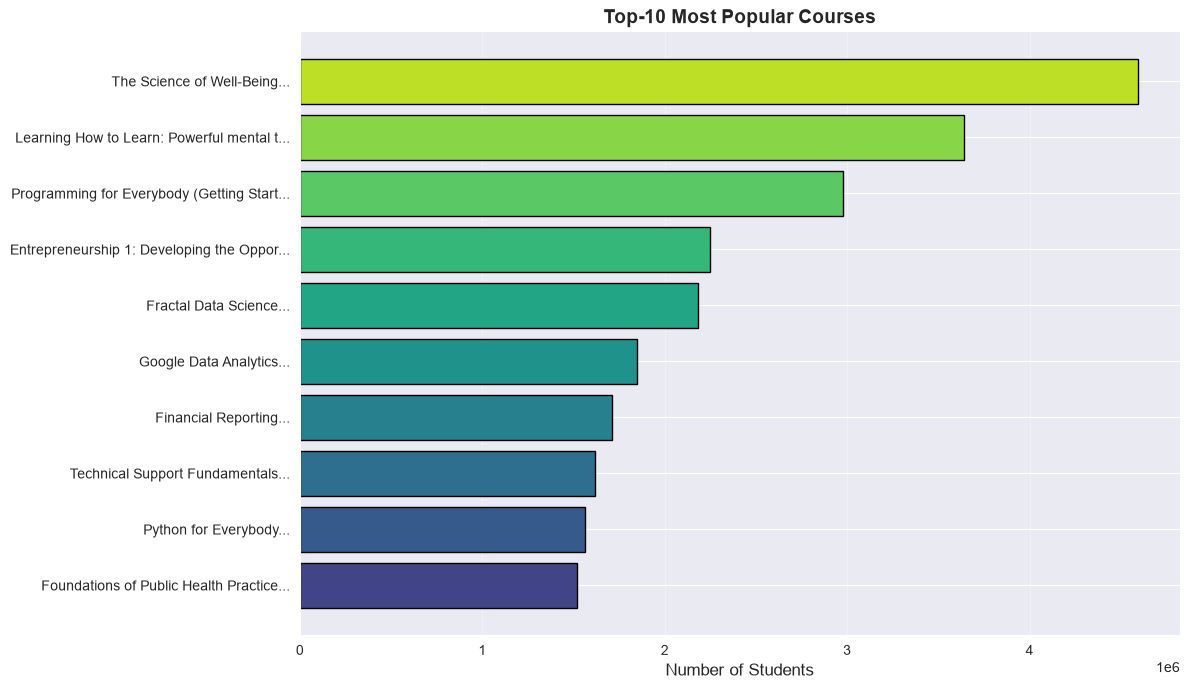

In [63]:
top_courses = df.nlargest(10, "students_clean")[
    ["course_title", "course_organization", "students_clean", "course_rating"]]

plt.figure(figsize=(12, 7))
bars = plt.barh(top_courses["course_title"].str[:40] + "...", top_courses["students_clean"],
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_courses)))[::-1], edgecolor="black")
plt.xlabel("Number of Students", fontsize=12)
plt.title("Top-10 Most Popular Courses", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод
Эти курсы - самые популярные, соответственно, при отстутствии данных о пользователей можно предлагать их, как самые популярные.